# Kenya Digital Payments Analysis
## : Exploratory Data Analysis & Visualisations
---
**Data Source:** Central Bank of Kenya (CBK)  
**Author:** Benard Musyoka Mwinzi
**Prerequisite:** Run `Digital Payments Data Cleaning.ipynb` first

### What This Notebook Covers
Using the clean datasets produced in Notebook 1, we generate **8 analytical charts** that tell the story of Kenya's digital payments transformation:

| # | Chart | Key Question |
|---|---|---|
| 1 | Mobile Money Growth | How fast have accounts and agents grown since 2007? |
| 2 | Volume & Value Trends | What's the monetary scale of mobile money? |
| 3 | Card Composition | How is the POS vs ATM split evolving? |
| 4 | POS Share Trend | Is Kenya moving away from cash? |
| 5 | COVID-19 Impact | How did the pandemic affect each channel? |
| 6 | Seasonality | Which months are busiest? |
| 7 | YoY Growth Rates | When did growth accelerate or slow? |
| 8 | Correlation Heatmap | How are the key metrics related? |

## 1. Setup — Libraries & Style Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette  ────────────────────────────
CBK_GREEN   = "#006633"
CBK_GOLD    = "#D4A017"
MOBILE_CLR  = "#1B7F4F"
CARD_CLR    = "#1A3C5E"
POS_CLR     = "#C0392B"
ATM_CLR     = "#2980B9"
HIGHLIGHT   = "#BA2413"


# ── Global plot style ─────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})


print("✅ Libraries and style configured")

✅ Libraries and style configured


## 2. Load Clean Data

In [3]:
mobile  = pd.read_csv("D:\Python\Digital Payments\Cleaned_Data\cleaned_mobile.csv", parse_dates=["date"])
cards   = pd.read_csv("D:\Python\Digital Payments\Cleaned_Data\cleaned_cards.csv", parse_dates=["date"])
merged  = pd.read_csv("D:\Python\Digital Payments\Cleaned_Data\cleaned_merged.csv", parse_dates=["date"])
overlap = merged[merged["card_data_available"]].copy()

print(f"✅ Datasets loaded")


✅ Datasets loaded


# EDA and Visualisations

### Chart 1 — Mobile Money Growth: Accounts & Agents
**Key insight:** Kenya's mobile money agent network and registered accounts have grown in lockstep,
with the COVID-19 fee waiver in 2020 providing a notable acceleration in account registrations.

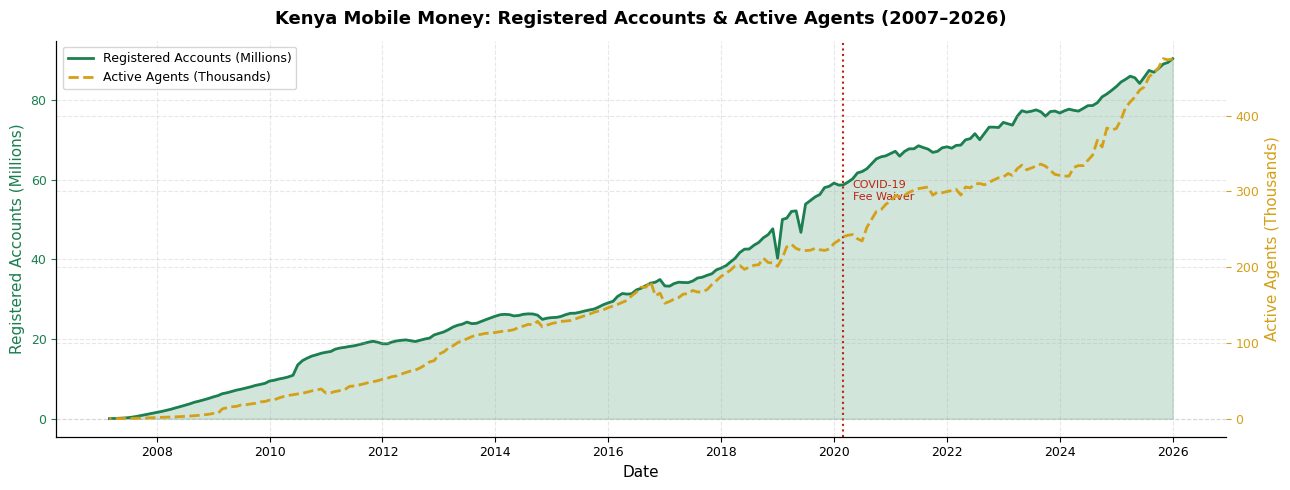

In [4]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Registered accounts (left axis)
ax1.fill_between(mobile["date"], mobile["registered_accounts_millions"],
                 alpha=0.2, color=MOBILE_CLR)
ax1.plot(mobile["date"], mobile["registered_accounts_millions"],
         color=MOBILE_CLR, lw=2, label="Registered Accounts (Millions)")

# Active agents (right axis)
ax2.plot(mobile["date"], mobile["active_agents"] / 1e3,
         color=CBK_GOLD, lw=2, linestyle="--", label="Active Agents (Thousands)")

# Annotate COVID fee waiver
ax1.axvline(pd.Timestamp("2020-03-01"), color=HIGHLIGHT, lw=1.5, linestyle=":")
ax1.text(pd.Timestamp("2020-05-01"), 55, "COVID-19\nFee Waiver", fontsize=8, color=HIGHLIGHT)

ax1.set_xlabel("Date")
ax1.set_ylabel("Registered Accounts (Millions)", color=MOBILE_CLR)
ax2.set_ylabel("Active Agents (Thousands)", color=CBK_GOLD)
ax1.tick_params(axis="y", colors=MOBILE_CLR)
ax2.tick_params(axis="y", colors=CBK_GOLD)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax1.set_title("Kenya Mobile Money: Registered Accounts & Active Agents (2007–2026)",
              fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

## Chart 2 — Mobile Money Transaction Volume & Value
**Key insight:** Transaction volume has grown from under 0.5M/month in 2007 to over 215M/month in 2026 —
a **500× increase**. The value of these transactions has grown even faster, reflecting rising
average transaction sizes as M-Pesa moves beyond small peer-to-peer transfers.

The growth is likely to be driven by driven by widespread adoption of mobile money services, expanding agent networks, and changing consumer behavior toward cashless transactions.

There is a temporary dip in transaction volume, followed by a sharp increase in transaction value.

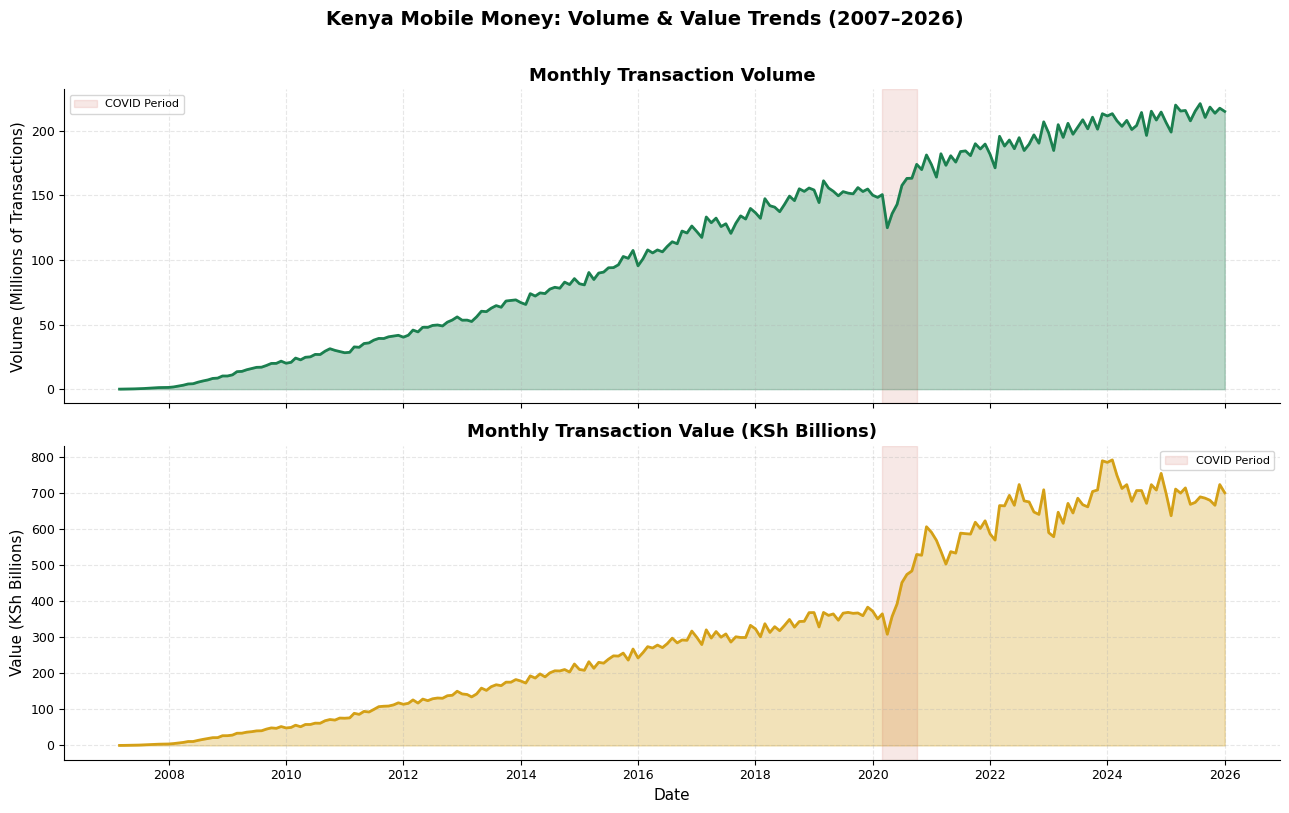

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.fill_between(mobile["date"], mobile["cash_in_out_volume_millions"],
                 alpha=0.3, color=MOBILE_CLR)
ax1.plot(mobile["date"], mobile["cash_in_out_volume_millions"],
         color=MOBILE_CLR, lw=2)
ax1.set_ylabel("Volume (Millions of Transactions)")
ax1.set_title("Monthly Transaction Volume", fontweight="bold")

ax2.fill_between(mobile["date"], mobile["cash_in_out_value_ksh_billions"],
                 alpha=0.3, color=CBK_GOLD)
ax2.plot(mobile["date"], mobile["cash_in_out_value_ksh_billions"],
         color=CBK_GOLD, lw=2)
ax2.set_ylabel("Value (KSh Billions)")
ax2.set_title("Monthly Transaction Value (KSh Billions)", fontweight="bold")
ax2.set_xlabel("Date")

for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-09-30"),
               alpha=0.1, color=HIGHLIGHT, label="COVID Period")
    ax.legend(fontsize=8)

fig.suptitle("Kenya Mobile Money: Volume & Value Trends (2007–2026)",
             fontweight="bold", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Chart 3 — Card Transaction Composition: POS vs ATM
**Key insight:** In 2009, ATM cash withdrawals dominated card usage. Over time, POS transactions
have grown dramatically, signalling Kenya's gradual shift from a cash economy toward 
electronic merchant payments.

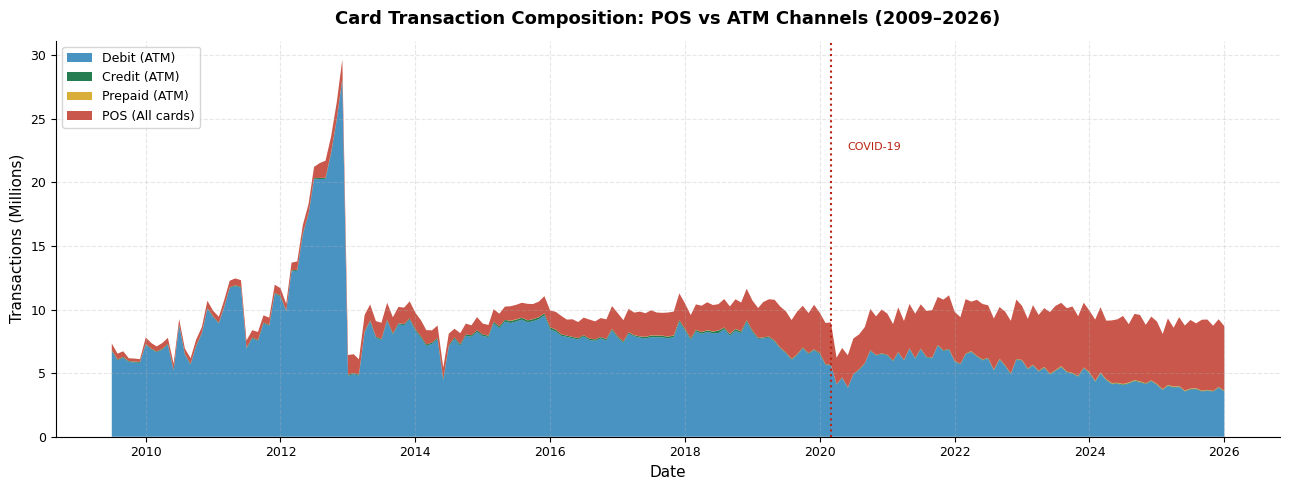

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.stackplot(
    cards["date"],
    cards["debit_atm"]  / 1e6,
    cards["credit_atm"] / 1e6,
    cards["prepaid_atm"]/ 1e6,
    cards["pos_total"]  / 1e6,
    labels=["Debit (ATM)", "Credit (ATM)", "Prepaid (ATM)", "POS (All cards)"],
    colors=[ATM_CLR, CBK_GREEN, CBK_GOLD, POS_CLR],
    alpha=0.85
)

ax.set_ylabel("Transactions (Millions)")
ax.set_xlabel("Date")
ax.set_title("Card Transaction Composition: POS vs ATM Channels (2009–2026)",
             fontweight="bold", pad=12)
ax.legend(loc="upper left", fontsize=9)
ax.axvline(pd.Timestamp("2020-03-01"), color=HIGHLIGHT, lw=1.5, linestyle=":")
ax.text(pd.Timestamp("2020-06-01"),
        cards["total_card_transactions"].max() * 0.8e-6,
        "COVID-19", fontsize=8, color=HIGHLIGHT)

fig.tight_layout()
plt.show()

## Chart 4 — POS Share of Card Transactions Over Time
**Key insight:** The POS share of card transactions has been trending upward, from around 4–8%
in 2009 to over 40% by 2024. This is a strong indicator of financial deepening — 
Kenyans increasingly use cards to pay for goods and services, not just to withdraw cash.

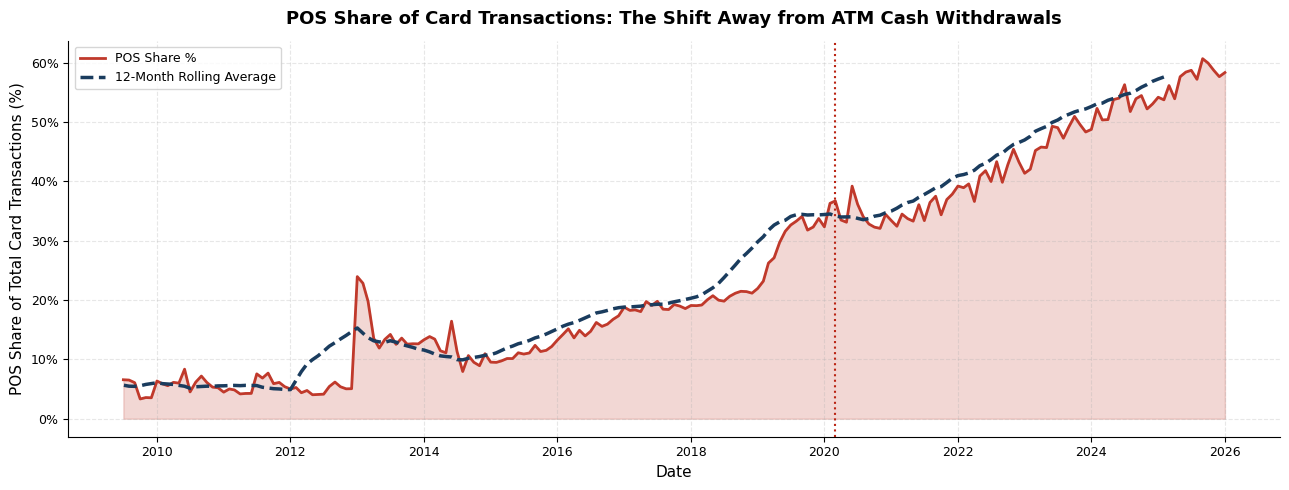

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(cards["date"], cards["pos_share_pct"], alpha=0.2, color=POS_CLR)
ax.plot(cards["date"], cards["pos_share_pct"], color=POS_CLR, lw=2, label="POS Share %")

# 12-month rolling average to smooth noise
rolling_pos = cards.set_index("date")["pos_share_pct"].rolling(12).mean()
ax.plot(rolling_pos.index, rolling_pos.values,
        color=CARD_CLR, lw=2.5, linestyle="--", label="12-Month Rolling Average")

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel("POS Share of Total Card Transactions (%)")
ax.set_xlabel("Date")
ax.set_title("POS Share of Card Transactions: The Shift Away from ATM Cash Withdrawals",
             fontweight="bold", pad=12)
ax.legend(fontsize=9)
ax.axvline(pd.Timestamp("2020-03-01"), color=HIGHLIGHT, lw=1.5, linestyle=":")
fig.tight_layout()
plt.show()

## Chart 5 — COVID-19 Impact (2019–2022 Zoom)
**Key insight:** The pandemic had sharply divergent effects on the two payment channels:
- **Card transactions** dropped significantly when lockdowns reduced physical retail activity
- **Mobile money** actually *increased* following the CBK fee waiver (March 2020), as users
  shifted to digital peer-to-peer transfers to avoid handling physical cash

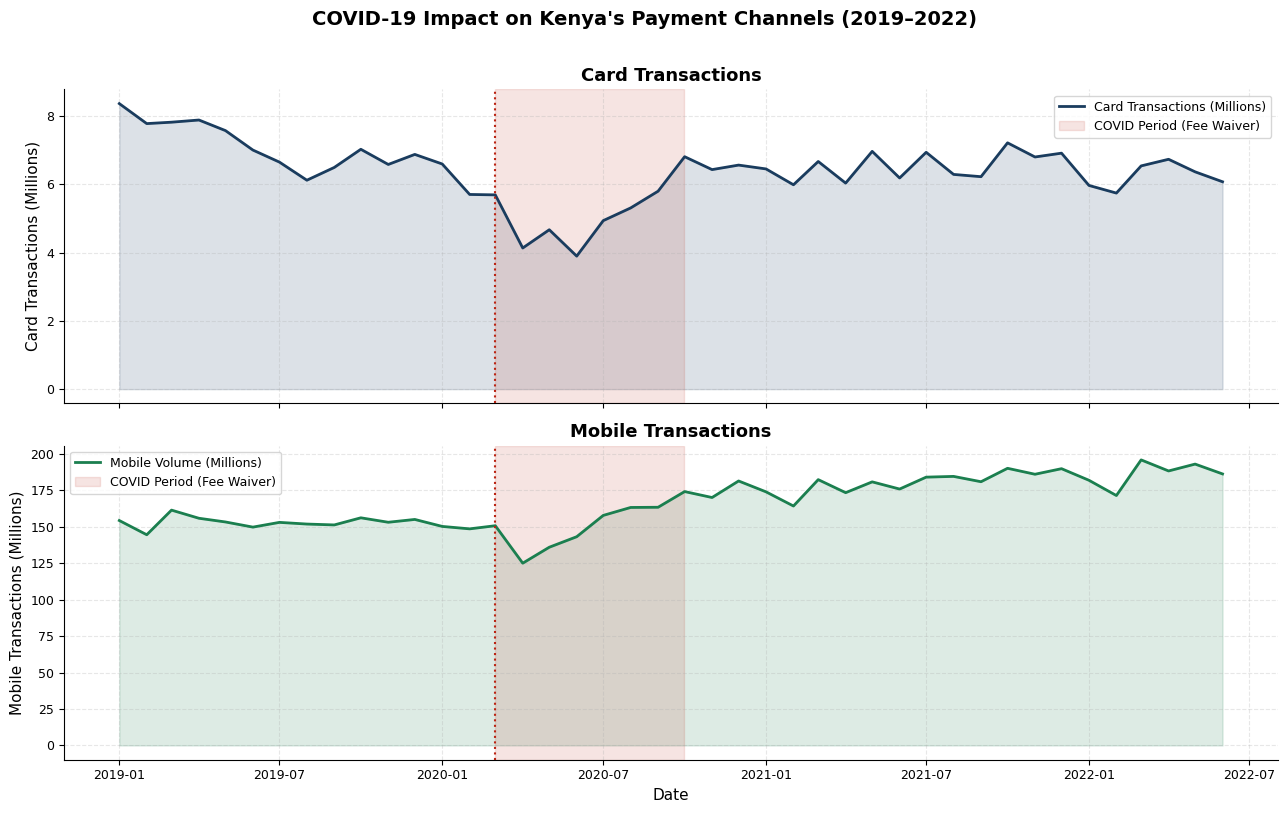

In [12]:
covid_window = overlap[(overlap["date"] >= "2019-01-01") & (overlap["date"] <= "2022-06-01")].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.plot(covid_window["date"], covid_window["total_card_transactions"] / 1e6,
         color=CARD_CLR, lw=2, label="Card Transactions (Millions)")
ax1.fill_between(covid_window["date"],
                 covid_window["total_card_transactions"] / 1e6,
                 alpha=0.15, color=CARD_CLR)
ax1.set_ylabel("Card Transactions (Millions)")
ax1.set_title("Card Transactions", fontweight="bold")

ax2.plot(covid_window["date"], covid_window["cash_in_out_volume_millions"],
         color=MOBILE_CLR, lw=2, label="Mobile Volume (Millions)")
ax2.fill_between(covid_window["date"],
                 covid_window["cash_in_out_volume_millions"],
                 alpha=0.15, color=MOBILE_CLR)
ax2.set_ylabel("Mobile Transactions (Millions)")
ax2.set_title("Mobile Transactions", fontweight="bold")
ax2.set_xlabel("Date")

for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-09-30"),
               alpha=0.12, color=HIGHLIGHT, label="COVID Period (Fee Waiver)")
    ax.axvline(pd.Timestamp("2020-03-01"), color=HIGHLIGHT, lw=1.5, linestyle=":")
    ax.legend(fontsize=9)

fig.suptitle("COVID-19 Impact on Kenya's Payment Channels (2019–2022)",
             fontweight="bold", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Chart 6 — Seasonality: Average Transactions by Month
**Key insight:** Both channels show a clear **December peak** driven by festive spending,
salary payments, and school-related transactions. January and February are consistently
the slowest months.

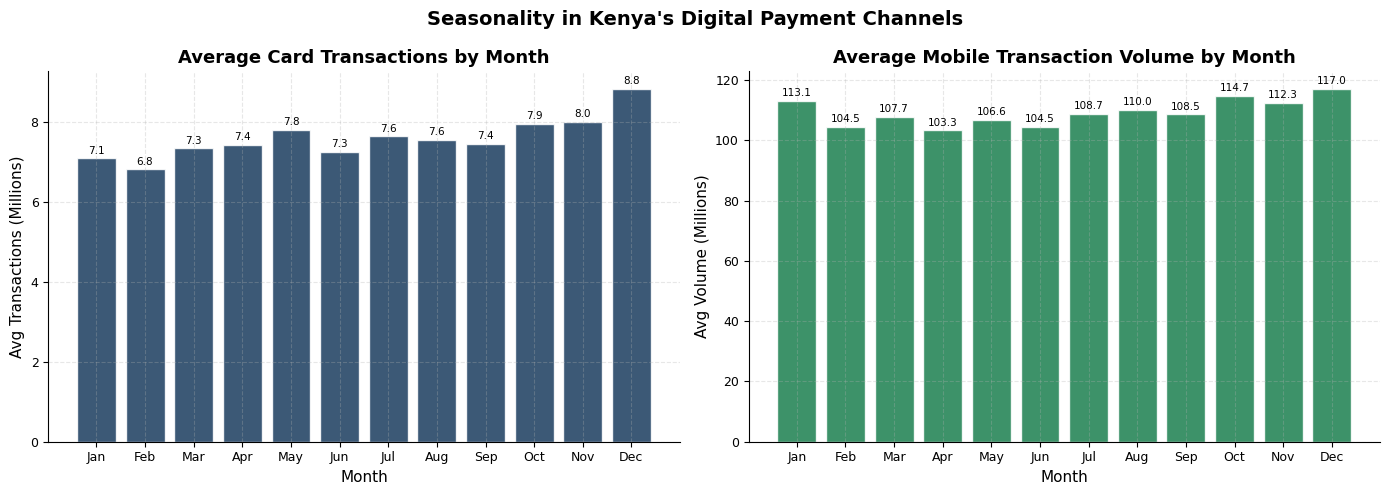

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

cards["month_abbr"] = cards["date"].dt.strftime("%b")
card_season = cards.groupby("month_abbr")["total_card_transactions"].mean() / 1e6
card_season = card_season.reindex(month_order)

bars1 = ax1.bar(month_order, card_season.values, color=CARD_CLR, alpha=0.85, edgecolor="white")
ax1.set_title("Average Card Transactions by Month", fontweight="bold")
ax1.set_ylabel("Avg Transactions (Millions)")
ax1.set_xlabel("Month")
ax1.bar_label(bars1, fmt="%.1f", fontsize=7.5, padding=2)

mobile["month_abbr"] = mobile["date"].dt.strftime("%b")
mobile_season = mobile.groupby("month_abbr")["cash_in_out_volume_millions"].mean()
mobile_season = mobile_season.reindex(month_order)

bars2 = ax2.bar(month_order, mobile_season.values, color=MOBILE_CLR, alpha=0.85, edgecolor="white")
ax2.set_title("Average Mobile Transaction Volume by Month", fontweight="bold")
ax2.set_ylabel("Avg Volume (Millions)")
ax2.set_xlabel("Month")
ax2.bar_label(bars2, fmt="%.1f", fontsize=7.5, padding=2)

fig.suptitle("Seasonality in Kenya's Digital Payment Channels",
             fontweight="bold", fontsize=14)
fig.tight_layout()
plt.show()

## Chart 7 — Year-over-Year Annual Growth Rates
**Key insight:** Mobile money showed explosive growth in its early years (2007–2012),
while card transactions have grown more steadily. Both channels show the COVID dip in 2020,
followed by strong recovery. Red bars = negative growth years.

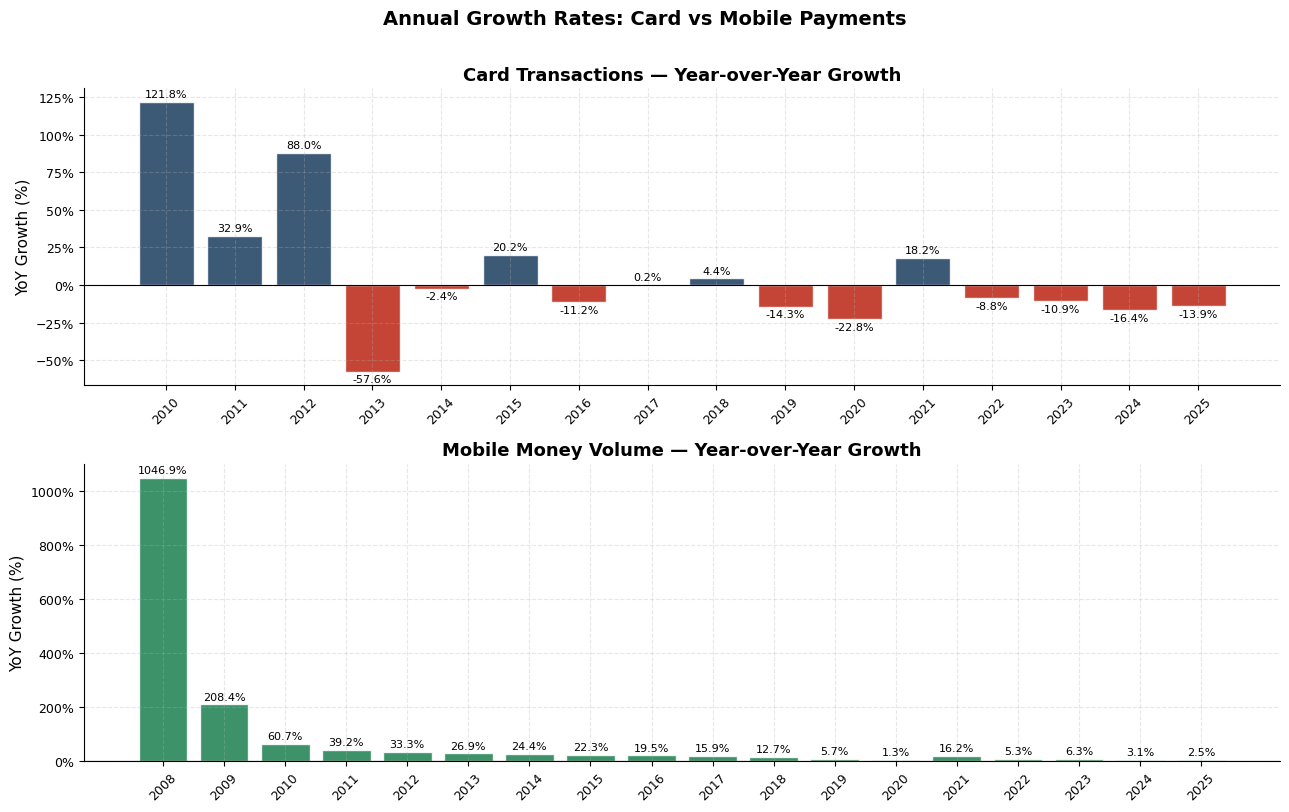

In [14]:
annual_cards  = cards.groupby("year")["total_card_transactions"].sum()
annual_mobile = mobile.groupby("year")["cash_in_out_volume_millions"].sum()

card_yoy   = annual_cards.pct_change()  * 100
mobile_yoy = annual_mobile.pct_change() * 100

# Filter to complete years only
card_yoy   = card_yoy[(card_yoy.index >= 2010)  & (card_yoy.index <= 2025)]
mobile_yoy = mobile_yoy[(mobile_yoy.index >= 2008) & (mobile_yoy.index <= 2025)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

def yoy_bar(ax, series, color, title):
    bar_colors = [color if v >= 0 else HIGHLIGHT for v in series.values]
    bars = ax.bar(series.index.astype(str), series.values,
                  color=bar_colors, alpha=0.85, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("YoY Growth (%)")
    ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
    ax.tick_params(axis="x", rotation=45)

yoy_bar(ax1, card_yoy,   CARD_CLR,   "Card Transactions — Year-over-Year Growth")
yoy_bar(ax2, mobile_yoy, MOBILE_CLR, "Mobile Money Volume — Year-over-Year Growth")

fig.suptitle("Annual Growth Rates: Card vs Mobile Payments",
             fontweight="bold", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Chart 8 — Correlation Heatmap
**Key insight:** Mobile money volume, registered accounts, and active agents are very highly
correlated (>0.99), confirming that agent network expansion drives adoption. Card transactions
show moderate correlation with mobile metrics — both are growing, but driven by different forces.

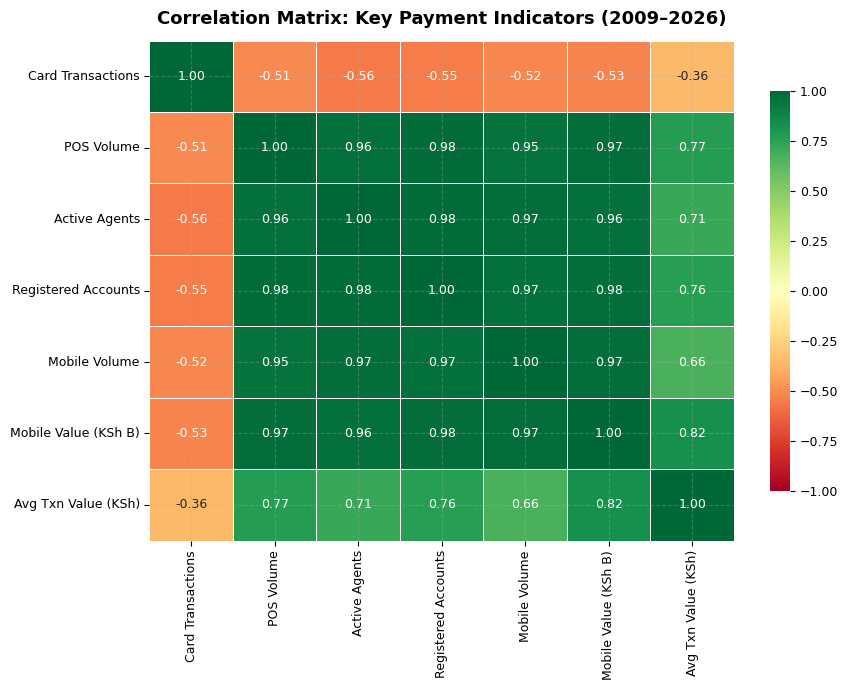

In [11]:
corr_cols = {
    "total_card_transactions":        "Card Transactions",
    "pos_total":                      "POS Volume",
    "active_agents":                  "Active Agents",
    "registered_accounts_millions":   "Registered Accounts",
    "cash_in_out_volume_millions":    "Mobile Volume",
    "cash_in_out_value_ksh_billions": "Mobile Value (KSh B)",
    "avg_transaction_value_ksh":      "Avg Txn Value (KSh)"
}

corr_data   = overlap[list(corr_cols.keys())].rename(columns=corr_cols)
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)
ax.set_title("Correlation Matrix: Key Payment Indicators (2009–2026)",
             fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

## 11. Summary of Findings

| Finding | Evidence |
|---|---|
| Mobile money has scaled 500× since 2007 | Volume: 0.02M → 215M monthly transactions |
| POS is replacing ATM as the dominant card channel | POS share: ~4% (2009) → 42%+ (2024) |
| COVID-19 diverged the two channels | Cards fell; mobile accelerated (fee waiver effect) |
| December is consistently the peak month | Both channels show strong festive-season spikes |
| Mobile ecosystem metrics are tightly linked | Accounts, agents & volume all correlate >0.99 |

---
**▶ Next step: Open `Notebook_03_Forecasting.ipynb`**